# Verify Rating Systems Work

In [1]:
import time
from itertools import combinations


import pandas as pd

from rating import (
    Game,
    Games,
    compare_rating_systems_winning_odds,
    compare_rating_systems_players_rating,
    compare_rating_systems_players_rating_pair,
    compare_rating_systems_players_rank,
    compare_rating_systems_players_ranking_pair,
)

from elo import EloSystem
from glicko2 import Glicko2System, GLICKO2_TO_ELO_SCALE, FIDE_STARTING_RATING
from simple_bayesian import SimpleBayesianSystem
from bayesian import BayesianSystem

# Simple Scenario

In [2]:
games: Games = [
    Game(
        player_a_name="Player A",
        player_b_name="Player B",
        outcome=1.0,  # Player A wins
    ),
    Game(
        player_a_name="Player B",
        player_b_name="Player C",
        outcome=0.0,  # Player B loses
    ),
    Game(
        player_a_name="Player C",
        player_b_name="Player A",
        outcome=0.5,  # Draw
    ),
    Game(
        player_a_name="Player B",
        player_b_name="Player C",
        outcome=1.0,  # Player B wins
    ),
    Game(
        player_a_name="Player C",
        player_b_name="Player A",
        outcome=0.0,  # Player C loses
    ),
    Game(
        player_a_name="Player B",
        player_b_name="Player C",
        outcome=0.5,  # Draw
    ),
    Game(
        player_a_name="Player A",
        player_b_name="Player C",
        outcome=1.0,  # Player A wins
    ),
    Game(
        player_a_name="Player B",
        player_b_name="Player A",
        outcome=0.0,  # Player B loses
    ),
    Game(
        player_a_name="Player C",
        player_b_name="Player B",
        outcome=1.0,  # Player C wins
    ),
    Game(
        player_a_name="Player A",
        player_b_name="Player C",
        outcome=0.5,  # Draw
    ),
]

## Rating Systems

### Elo

In [3]:
elo_rating = EloSystem(verbose=True)

elo_rating.add_player(name="Player A", rating=1500, games_played=51)
elo_rating.add_player(name="Player B", rating=800, games_played=27)
elo_rating.add_player(name="Player C")
elo_rating.add_player(name="Player D")

elo_rating.update_ratings(games)

Updating rating for Player A vs Player B
Current rating: 1500 vs 800
Nb games played: 51 vs 27
Outcome for Player A: 1.0
New rating: 1500.35 vs 799.30

Updating rating for Player B vs Player C
Current rating: 799.3011163402067 vs 1000.0
Nb games played: 28 vs 0
Outcome for Player B: 0.0
New rating: 789.72 vs 1009.58

Updating rating for Player C vs Player A
Current rating: 1009.5807799485989 vs 1500.3494418298967
Nb games played: 1 vs 52
Outcome for Player C: 0.5
New rating: 1027.34 vs 1491.47

Updating rating for Player B vs Player C
Current rating: 789.7203363916078 vs 1027.3414502479573
Nb games played: 29 vs 2
Outcome for Player B: 1.0
New rating: 821.60 vs 995.46

Updating rating for Player C vs Player A
Current rating: 995.4601017282555 vs 1491.4691066802175
Nb games played: 3 vs 53
Outcome for Player C: 0.0
New rating: 993.28 vs 1492.56

Updating rating for Player B vs Player C
Current rating: 821.6016849113096 vs 993.2836939926605
Nb games played: 30 vs 4
Outcome for Player B: 

In [4]:
elo_rating.display_players()

Ratings:
Player A: 1485.06
Player B: 819.98
Player C: 1011.54
Player D: 1000.00

Number of played games:
Player A: 57
Player B: 33
Player C: 8
Player D: 0



In [5]:
_ = elo_rating.compute_winning_odds("Player B", "Player C")

Winning probability: 24.92
Loosing probability: 75.08
Drawing probability: 0.00


### Glicko-2

In [6]:
# Compute starting points for Glicko2 to be compatible with above
player_a_rating = (1500 - 1000) / GLICKO2_TO_ELO_SCALE
player_a_rating_uncertainty = 100 / GLICKO2_TO_ELO_SCALE
player_b_rating = (800 - 1000) / GLICKO2_TO_ELO_SCALE
player_b_rating_uncertainty = 50 / GLICKO2_TO_ELO_SCALE

In [7]:
glicko2_rating = Glicko2System(verbose=True)

glicko2_rating.add_player(
    name="Player A",
    rating=player_a_rating,
    rating_uncertainty=player_a_rating_uncertainty,
    volatility=0.07,
)
glicko2_rating.add_player(
    name="Player B",
    rating=player_b_rating,
    rating_uncertainty=player_b_rating_uncertainty,
    volatility=0.05,
)
glicko2_rating.add_player(name="Player C")
glicko2_rating.add_player(name="Player D")

glicko2_rating.update_ratings(games)

Initial brackets for volatility: [-5.318520073865556, -5.818520073865556]
Brackets for volatility: [-5.318520073865556, -5.318607928810409]
Brackets for volatility: [-5.318607928810409, -5.31860792552637]
Volatility: 0.06999692514446595

Initial brackets for volatility: [-5.991464547107982, -6.491464547107982]
Brackets for volatility: [-5.991464547107982, -5.991588649301823]
Brackets for volatility: [-5.991588649301823, -5.991588642757172]
Volatility: 0.04999689754141045

Initial brackets for volatility: [-5.626821433520073, -6.126821433520073]
Brackets for volatility: [-5.626821433520073, -5.626908085399224]
Brackets for volatility: [-5.626908085399224, -5.626908082205868]
Volatility: 0.05999740049993876



In [8]:
glicko2_rating.display_players()

Ratings:
Player A: 2.79
Player B: -1.14
Player C: 0.17
Player D: 0.00

Uncertainty:
Player A: 0.56
Player B: 0.29
Player C: 0.92
Player D: 2.02

Volatility:
Player A: 0.06999693
Player B: 0.04999690
Player C: 0.05999740
Player D: 0.06000000

Rating (Elo Scale):
Player A: 1484.1681408603943
Player B: 801.6697023167043
Player C: 1029.784738531771
Player D: 1000.0

Rating Uncertainty (Elo Scale):
Player A: 96.9933680574934
Player B: 49.853318601274786
Player C: 160.60135533216393
Player D: 350.1551660870916



In [9]:
_ = glicko2_rating.compute_winning_odds("Player B", "Player C")

Winning probability: 23.69
Loosing probability: 76.31
Drawing probability: 0.00


### Simple Bayesian

In [10]:
simple_bayesian_system = SimpleBayesianSystem(verbose=True)

simple_bayesian_system.add_player(name="Player A", rating=1.5)
simple_bayesian_system.add_player(name="Player B", rating=0.8)
simple_bayesian_system.add_player(name="Player C")
simple_bayesian_system.add_player(name="Player D")

simple_bayesian_system.update_ratings(games)

Converged in 27 iterations.


In [11]:
simple_bayesian_system.display_players()

Ratings:
Player A: 1.33
Player B: 0.64
Player C: 0.89
Player D: 1.00



In [12]:
_ = simple_bayesian_system.compute_winning_odds("Player B", "Player C")

Winning probability: 41.86
Loosing probability: 58.14
Drawing probability: 0.00


### Bayesian

In [13]:
bayesian_system = BayesianSystem(
    first_advantage=25,
    draw_bias=10,
    verbose=True,
)

bayesian_system.add_player(name="Player A", rating=1.5)
bayesian_system.add_player(name="Player B", rating=0.8)
bayesian_system.add_player(name="Player C")
bayesian_system.add_player(name="Player D")

bayesian_system.update_ratings(games)

Number of iterations: 7


In [14]:
bayesian_system.display_players()

Ratings:
Player A: 913.29
Player B: 522.66
Player C: 665.53
Player D: 1000.00



In [15]:
_ = bayesian_system.compute_winning_odds("Player B", "Player C", is_first=True)

Winning probability: 32.39
Loosing probability: 65.04
Drawing probability: 2.57


In [16]:
_ = bayesian_system.compute_winning_odds("Player B", "Player C", is_first=False)

Winning probability: 26.43
Loosing probability: 71.27
Drawing probability: 2.30


## Compare Rating Systems

In [17]:
rating_systems = [elo_rating, glicko2_rating, simple_bayesian_system, bayesian_system]
players = ["Player A", "Player B", "Player C", "Player D"]

### Ratings

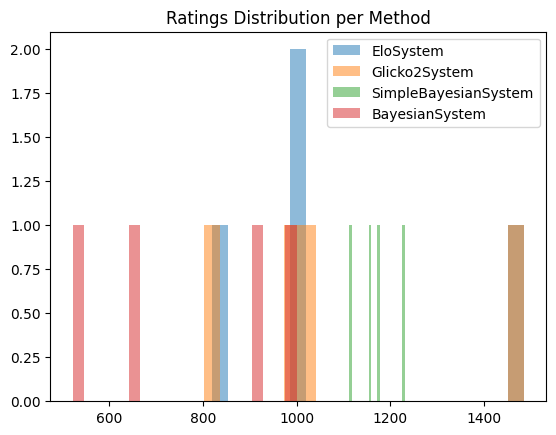

,Player A,Player B,Player C,Player D
EloSystem,1485.057220,819.975509,1011.536226,1000.000000
Glicko2System,1484.168141,801.669702,1029.784739,1000.000000
SimpleBayesianSystem,1231.774533,1111.693202,1155.126073,1173.717793
BayesianSystem,913.293512,522.662447,665.528262,1000.000000


In [18]:
df_ratings = compare_rating_systems_players_rating(
    rating_systems,
    players,
    corrective_addition_factors=[
        0.0,
        FIDE_STARTING_RATING,
        FIDE_STARTING_RATING,
        0.0,
    ],
    corrective_multiplication_factors=[
        1.0,
        GLICKO2_TO_ELO_SCALE,
        GLICKO2_TO_ELO_SCALE,
        1.0,
    ],
)

df_ratings

--------------------------------------------------
COMPARING EloSystem vs Glicko2System
--------------------------------------------------
Rating Difference:
count     4.000000
mean      0.236593
std      14.929583
min     -18.248512
25%      -4.562128
50%       0.444540
75%       5.243261
max      18.305807
dtype: float64
Absolute Rating Difference:
count     4.000000
mean      9.360850
std      10.302091
min       0.000000
25%       0.666809
50%       9.568796
75%      18.262836
max      18.305807
dtype: float64


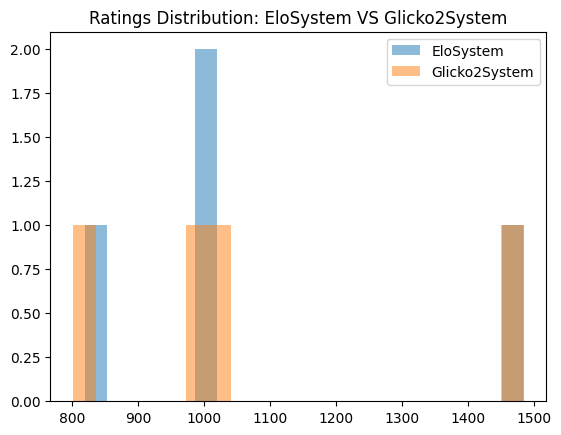

--------------------------------------------------
COMPARING EloSystem vs SimpleBayesianSystem
--------------------------------------------------
Rating Difference:
count      4.000000
mean     -88.935662
std      236.931101
min     -291.717693
25%     -203.217768
50%     -158.653820
75%      -44.371714
max      253.282687
dtype: float64
Absolute Rating Difference:
count      4.000000
mean     215.577005
std       68.686407
min      143.589847
25%      166.185806
50%      213.500240
75%      262.891439
max      291.717693
dtype: float64


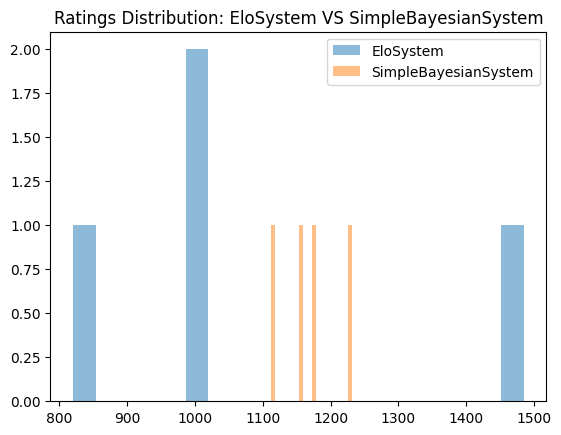

--------------------------------------------------
COMPARING EloSystem vs BayesianSystem
--------------------------------------------------
Rating Difference:
count      4.000000
mean     303.771184
std      235.175522
min        0.000000
25%      222.984797
50%      321.660513
75%      402.446900
max      571.763708
dtype: float64
Absolute Rating Difference:
count      4.000000
mean     303.771184
std      235.175522
min        0.000000
25%      222.984797
50%      321.660513
75%      402.446900
max      571.763708
dtype: float64


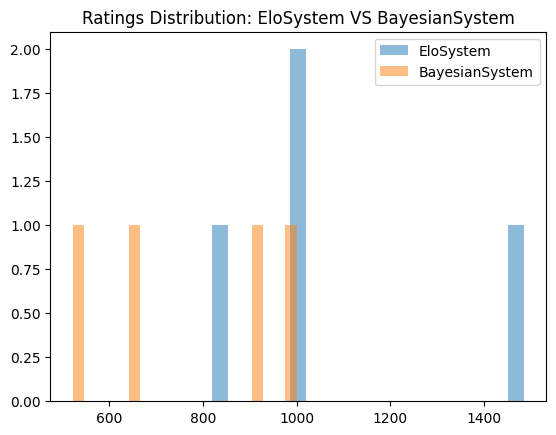

--------------------------------------------------
COMPARING Glicko2System vs SimpleBayesianSystem
--------------------------------------------------
Rating Difference:
count      4.000000
mean     -89.172255
std      240.761750
min     -310.023500
25%     -207.794220
50%     -149.529564
75%      -30.907599
max      252.393608
dtype: float64
Absolute Rating Difference:
count      4.000000
mean     215.369059
std       81.996137
min      125.341335
25%      161.623678
50%      213.055700
75%      266.801081
max      310.023500
dtype: float64


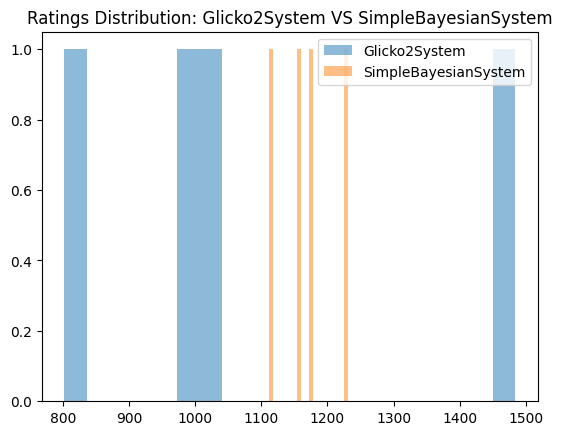

--------------------------------------------------
COMPARING Glicko2System vs BayesianSystem
--------------------------------------------------
Rating Difference:
count      4.000000
mean     303.534590
std      236.567595
min        0.000000
25%      209.255442
50%      321.631866
75%      415.911015
max      570.874629
dtype: float64
Absolute Rating Difference:
count      4.000000
mean     303.534590
std      236.567595
min        0.000000
25%      209.255442
50%      321.631866
75%      415.911015
max      570.874629
dtype: float64


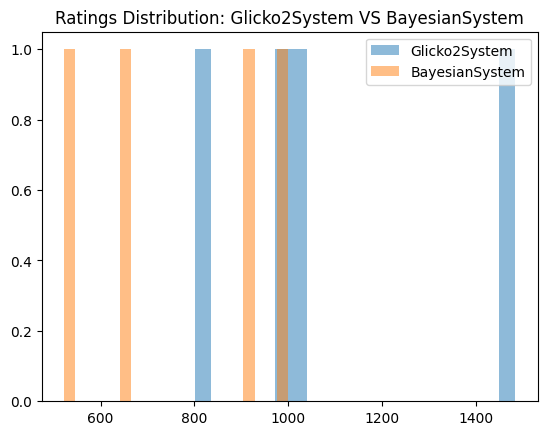

--------------------------------------------------
COMPARING SimpleBayesianSystem vs BayesianSystem
--------------------------------------------------
Rating Difference:
count      4.000000
mean     392.706845
std      183.844695
min      173.717793
25%      282.290214
50%      404.039416
75%      514.456048
max      589.030756
dtype: float64
Absolute Rating Difference:
count      4.000000
mean     392.706845
std      183.844695
min      173.717793
25%      282.290214
50%      404.039416
75%      514.456048
max      589.030756
dtype: float64


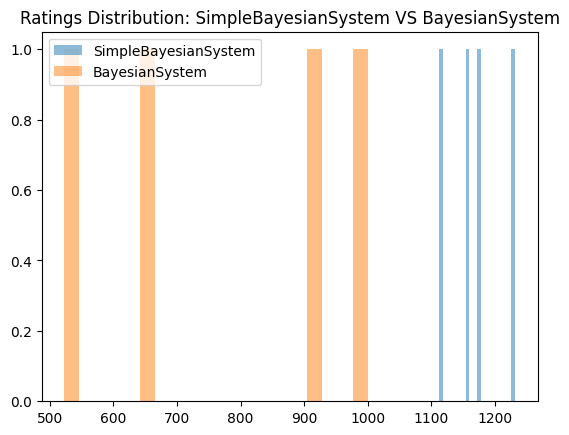

In [19]:
for rating_system_a, rating_system_b in combinations(rating_systems, 2):
    rating_system_a_name = rating_system_a.__class__.__name__
    rating_system_b_name = rating_system_b.__class__.__name__

    print("-" * 50)
    print(f"COMPARING {rating_system_a_name} vs {rating_system_b_name}")
    print("-" * 50)

    compare_rating_systems_players_rating_pair(
        df_ratings, rating_system_a_name, rating_system_b_name
    )

### Rank

In [20]:
df_ranking = compare_rating_systems_players_rank(rating_systems, players)

df_ranking

,Player A,Player B,Player C,Player D
EloSystem,1,4,2,3
Glicko2System,1,4,2,3
SimpleBayesianSystem,1,4,3,2
BayesianSystem,2,4,3,1


--------------------------------------------------
COMPARING EloSystem vs Glicko2System
--------------------------------------------------
Ranking Difference:
count    4.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64
Absolute Ranking Difference:
count    4.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
dtype: float64


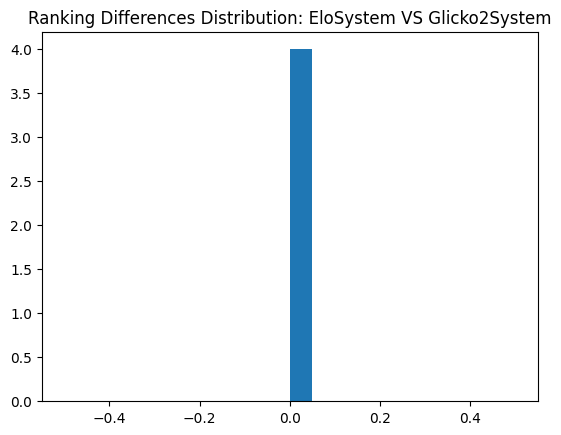

--------------------------------------------------
COMPARING EloSystem vs SimpleBayesianSystem
--------------------------------------------------
Ranking Difference:
count    4.000000
mean     0.000000
std      0.816497
min     -1.000000
25%     -0.250000
50%      0.000000
75%      0.250000
max      1.000000
dtype: float64
Absolute Ranking Difference:
count    4.00000
mean     0.50000
std      0.57735
min      0.00000
25%      0.00000
50%      0.50000
75%      1.00000
max      1.00000
dtype: float64


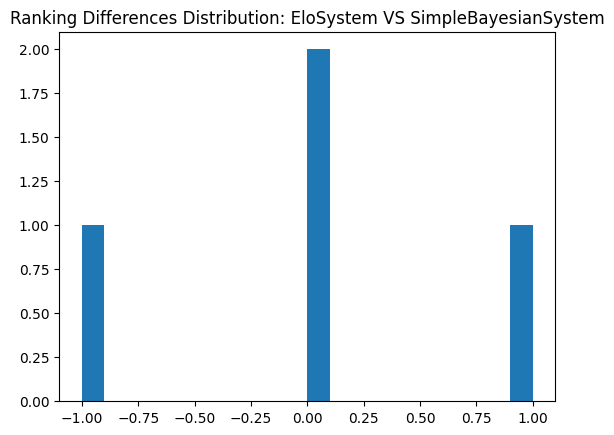

--------------------------------------------------
COMPARING EloSystem vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    4.000000
mean     0.000000
std      1.414214
min     -1.000000
25%     -1.000000
50%     -0.500000
75%      0.500000
max      2.000000
dtype: float64
Absolute Ranking Difference:
count    4.000000
mean     1.000000
std      0.816497
min      0.000000
25%      0.750000
50%      1.000000
75%      1.250000
max      2.000000
dtype: float64


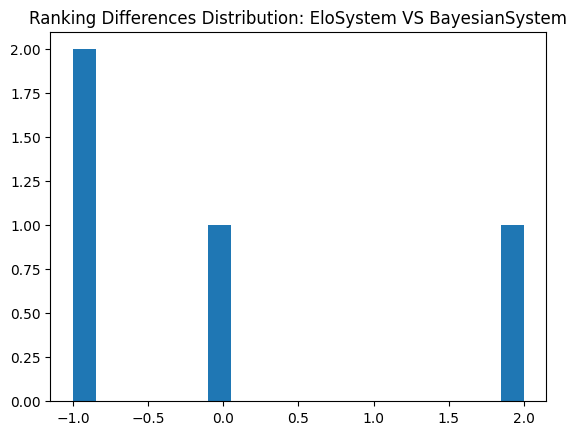

--------------------------------------------------
COMPARING Glicko2System vs SimpleBayesianSystem
--------------------------------------------------
Ranking Difference:
count    4.000000
mean     0.000000
std      0.816497
min     -1.000000
25%     -0.250000
50%      0.000000
75%      0.250000
max      1.000000
dtype: float64
Absolute Ranking Difference:
count    4.00000
mean     0.50000
std      0.57735
min      0.00000
25%      0.00000
50%      0.50000
75%      1.00000
max      1.00000
dtype: float64


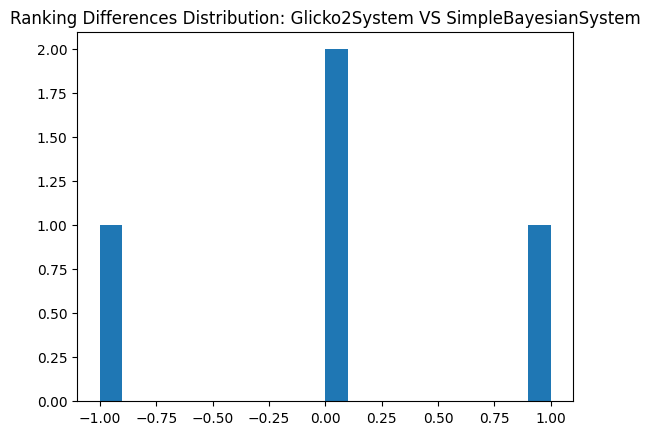

--------------------------------------------------
COMPARING Glicko2System vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    4.000000
mean     0.000000
std      1.414214
min     -1.000000
25%     -1.000000
50%     -0.500000
75%      0.500000
max      2.000000
dtype: float64
Absolute Ranking Difference:
count    4.000000
mean     1.000000
std      0.816497
min      0.000000
25%      0.750000
50%      1.000000
75%      1.250000
max      2.000000
dtype: float64


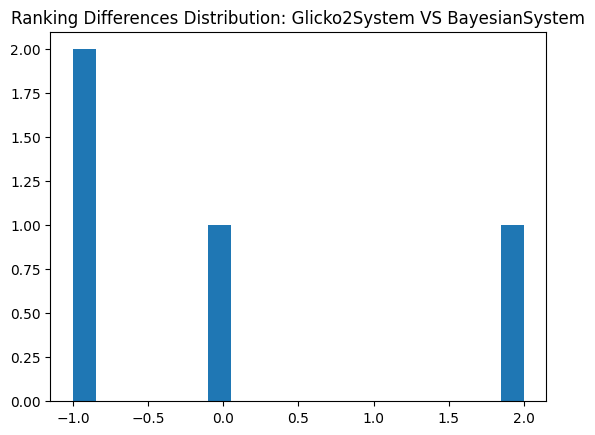

--------------------------------------------------
COMPARING SimpleBayesianSystem vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    4.000000
mean     0.000000
std      0.816497
min     -1.000000
25%     -0.250000
50%      0.000000
75%      0.250000
max      1.000000
dtype: float64
Absolute Ranking Difference:
count    4.00000
mean     0.50000
std      0.57735
min      0.00000
25%      0.00000
50%      0.50000
75%      1.00000
max      1.00000
dtype: float64


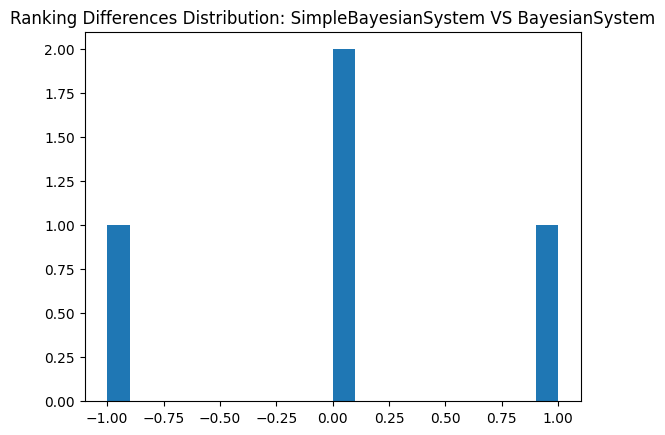

In [21]:
for rating_system_a, rating_system_b in combinations(rating_systems, 2):
    rating_system_a_name = rating_system_a.__class__.__name__
    rating_system_b_name = rating_system_b.__class__.__name__

    print("-" * 50)
    print(f"COMPARING {rating_system_a_name} vs {rating_system_b_name}")
    print("-" * 50)

    compare_rating_systems_players_ranking_pair(
        df_ranking, rating_system_a_name, rating_system_b_name
    )

### Winning odds

In [22]:
compare_rating_systems_winning_odds(
    rating_systems, "Player B", "Player C", is_first=False
)

Winning probability: 24.92
Loosing probability: 75.08
Drawing probability: 0.00
Winning probability: 23.69
Loosing probability: 76.31
Drawing probability: 0.00
Winning probability: 41.86
Loosing probability: 58.14
Drawing probability: 0.00
Winning probability: 26.43
Loosing probability: 71.27
Drawing probability: 2.30


,winning_proba,loosing_proba,drawing_proba
EloSystem,24.923207,75.076793,0.000000
Glicko2System,23.686776,76.313224,0.000000
SimpleBayesianSystem,41.860995,58.139005,0.000000
BayesianSystem,26.427271,71.274404,2.298325


In [23]:
compare_rating_systems_winning_odds(
    rating_systems, "Player B", "Player C", is_first=True
)

Winning probability: 24.92
Loosing probability: 75.08
Drawing probability: 0.00
Winning probability: 23.69
Loosing probability: 76.31
Drawing probability: 0.00
Winning probability: 41.86
Loosing probability: 58.14
Drawing probability: 0.00
Winning probability: 32.39
Loosing probability: 65.04
Drawing probability: 2.57


,winning_proba,loosing_proba,drawing_proba
EloSystem,24.923207,75.076793,0.000000
Glicko2System,23.686776,76.313224,0.000000
SimpleBayesianSystem,41.860995,58.139005,0.000000
BayesianSystem,32.386745,65.042902,2.570353


# Advanced 

Dataset of *Lichess* games, considering only the classical games

In [24]:
df = pd.read_parquet("others/train-00000-of-00001.parquet")
df = df[df["Event"] == "Rated Classical game"].copy()
# df = df.iloc[:1000]
df = df.sort_values("UTCTime")
print(df.shape)
print(df.columns)
df.sample(5)

(41772, 18)
Index(['Event', 'Site', 'White', 'Black', 'Result', 'WhiteTitle', 'BlackTitle',
       'WhiteElo', 'BlackElo', 'WhiteRatingDiff', 'BlackRatingDiff', 'UTCDate',
       'UTCTime', 'ECO', 'Opening', 'Termination', 'TimeControl', 'movetext'],
      dtype='object')


,Event,Site,White,Black,Result,WhiteTitle,BlackTitle,WhiteElo,BlackElo,WhiteRatingDiff,BlackRatingDiff,UTCDate,UTCTime,ECO,Opening,Termination,TimeControl,movetext
69525,Rated Classical game,https://lichess.org/7tvxqj4m,olinchuk,Thunderbird,1-0,None,None,1831.0,1482.0,3.0,-3.0,2013-01-19,0 days 07:06:49,B07,Pirc Defense #4,Normal,300+8,1. e4 d6 2. Bc4 c5 3. Qh5 g6 4. Qf3 Nf6 5. h3 ...
80605,Rated Classical game,https://lichess.org/27hi0887,Kiriush,NOCKA,1-0,None,None,1947.0,1802.0,9.0,-7.0,2013-01-21,0 days 22:06:56,B38,"Sicilian Defense: Accelerated Dragon, Maroczy ...",Normal,300+8,1. e4 c5 2. Nf3 Nc6 3. d4 cxd4 4. Nxd4 g6 5. c...
43335,Rated Classical game,https://lichess.org/e2wtig33,FashionBoy,ETO_GOLOVA,1-0,None,None,1634.0,1798.0,16.0,-42.0,2013-01-12,0 days 06:02:50,C40,King's Knight Opening,Normal,300+8,1. e4 e5 2. Nf3 Bd6 3. c3 c5 4. d3 Qb6 5. Be2 ...
117611,Rated Classical game,https://lichess.org/x23n8hun,Tomi,GladiatorX1,1-0,None,None,1649.0,1563.0,8.0,-8.0,2013-01-31,0 days 02:48:06,C55,Italian Game: Anti-Fried Liver Defense,Normal,600+1,1. e4 { [%eval 0.22] } 1... e5 { [%eval 0.21] ...
95503,Rated Classical game,https://lichess.org/b6nnwwxk,red_indian_army,TEODOR,0-1,None,None,1500.0,1719.0,-93.0,5.0,2013-01-25,0 days 19:04:14,C20,"King's Pawn Game: Wayward Queen Attack, Kiddie...",Normal,300+8,1. e4 e5 2. Qh5 Nf6 3. Qxe5+ Be7 4. d3 Nc6 5. ...


In [25]:
players_names = (pd.concat([df["White"], df["Black"]])).unique()
len(players_names)

3524

In [26]:
games: list[Game] = []

for _, row in df.iterrows():
    player_a_name = row.loc["White"]
    player_b_name = row.loc["Black"]
    outcome = row.loc["Result"]

    if outcome == "1-0":
        outcome = 1.0
    elif outcome == "0-1":
        outcome = 0.0
    elif outcome == "1/2-1/2":
        outcome = 0.5
    else:
        continue

    games.append(
        Game(player_a_name=player_a_name, player_b_name=player_b_name, outcome=outcome)
    )

## Rating Systems

### Elo

In [27]:
start_time = time.time()

elo_rating = EloSystem()

for player_name in players_names:
    elo_rating.add_player(name=player_name)

elo_rating.update_ratings(games)

In [28]:
print(f"Computation took {time.time()-start_time:.2f} seconds")

Computation took 0.09 seconds


In [29]:
player_1 = elo_rating.players[list(elo_rating.players.keys())[0]]
player_1_name = player_1["name"]
player_1

{'name': 'koishiteru2', 'rating': 1091.1490858112047, 'games_played': 65}

In [30]:
player_2 = elo_rating.players[list(elo_rating.players.keys())[2]]
player_2_name = player_2["name"]
player_2

{'name': 'www_aglona_travel', 'rating': 877.345720499127, 'games_played': 38}

In [31]:
elo_rating.verbose = True
_ = elo_rating.compute_winning_odds(player_1_name, player_2_name)

Winning probability: 77.40
Loosing probability: 22.60
Drawing probability: 0.00


### Glicko-2

In [32]:
start_time = time.time()

glicko2_rating = Glicko2System()

for player_name in players_names:
    glicko2_rating.add_player(name=player_name)


glicko2_rating.update_ratings(games)

print(f"Computation took {time.time()-start_time:.2f} seconds")

Computation took 10.03 seconds


In [33]:
glicko2_rating.verbose = True
_ = glicko2_rating.compute_winning_odds(player_1_name, player_2_name)

Winning probability: 73.22
Loosing probability: 26.78
Drawing probability: 0.00


### Simple Bayesian

In [34]:
start_time = time.time()

simple_bayesian_system = SimpleBayesianSystem()

for player_name in players_names:
    simple_bayesian_system.add_player(name=player_name)

simple_bayesian_system.update_ratings(games)

print(f"Computation took {time.time()-start_time:.2f} seconds")

Computation took 59.63 seconds


In [35]:
simple_bayesian_system.verbose = True
_ = simple_bayesian_system.compute_winning_odds(player_1_name, player_2_name)

Winning probability: 58.89
Loosing probability: 41.11
Drawing probability: 0.00


### Bayesian

In [36]:
start_time = time.time()

bayesian_system = BayesianSystem(verbose=True)

for player_name in players_names:
    bayesian_system.add_player(name=player_name)

bayesian_system.update_ratings(games)

print(f"Computation took {time.time()-start_time:.2f} seconds")

Number of iterations: 2
Computation took 1110.90 seconds


In [37]:
_ = bayesian_system.compute_winning_odds(player_1_name, player_2_name, is_first=True)

Winning probability: 41.71
Loosing probability: 31.32
Drawing probability: 26.98


In [38]:
_ = bayesian_system.compute_winning_odds(player_1_name, player_2_name, is_first=False)

Winning probability: 32.90
Loosing probability: 39.95
Drawing probability: 27.15


## Compare Rating Systems

In [39]:
rating_systems = [elo_rating, glicko2_rating, simple_bayesian_system, bayesian_system]
players = players_names

### Ratings

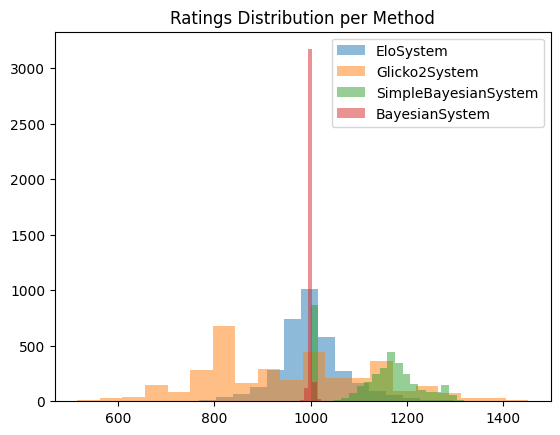

In [40]:
df_ratings = compare_rating_systems_players_rating(
    rating_systems,
    players,
    corrective_addition_factors=[
        1.0,
        FIDE_STARTING_RATING,
        FIDE_STARTING_RATING,
        0.0,
    ],
    corrective_multiplication_factors=[
        1.0,
        GLICKO2_TO_ELO_SCALE,
        GLICKO2_TO_ELO_SCALE,
        1.0,
    ],
)

--------------------------------------------------
COMPARING EloSystem vs Glicko2System
--------------------------------------------------
Rating Difference:
count    3524.000000
mean       40.766541
std       125.206118
min      -319.975218
25%       -38.997947
50%        41.501725
75%       143.310895
max       309.039170
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean      108.082360
std        75.192034
min         0.005030
25%        40.504402
50%       107.669059
75%       148.238619
max       319.975218
dtype: float64


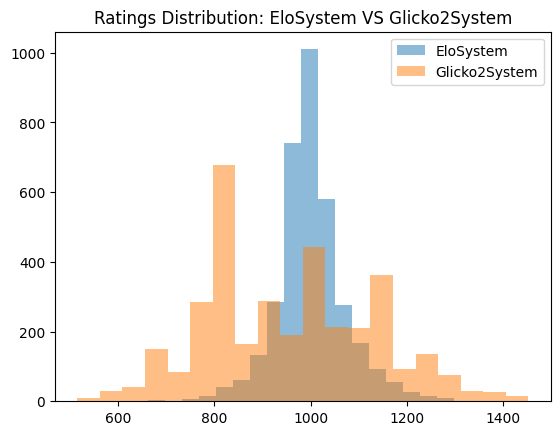

--------------------------------------------------
COMPARING EloSystem vs SimpleBayesianSystem
--------------------------------------------------
Rating Difference:
count    3524.000000
mean     -133.909818
std        78.421878
min      -438.675559
25%      -181.236503
50%      -151.675056
75%       -58.274562
max        93.593933
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean      134.344671
std        77.674362
min         1.005743
25%        58.586768
50%       151.675056
75%       181.236503
max       438.675559
dtype: float64


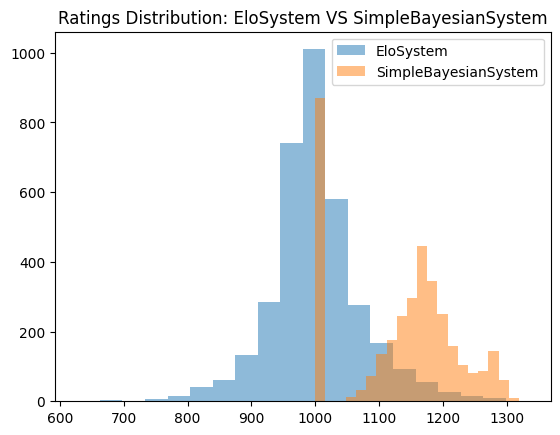

--------------------------------------------------
COMPARING EloSystem vs BayesianSystem
--------------------------------------------------
Rating Difference:
count    3524.000000
mean        0.248750
std        69.157263
min      -352.904387
25%       -33.116061
50%        -9.114007
75%        28.024087
max       326.253308
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean       49.318318
std        48.474757
min         0.019328
25%        16.917792
50%        31.643896
75%        66.496088
max       352.904387
dtype: float64


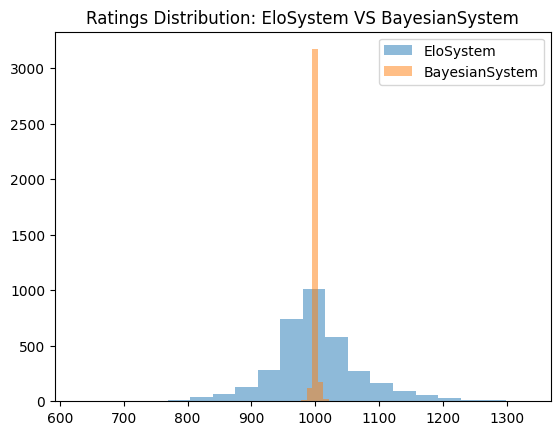

--------------------------------------------------
COMPARING Glicko2System vs SimpleBayesianSystem
--------------------------------------------------
Rating Difference:
count    3524.000000
mean     -174.676359
std       109.100411
min      -567.133882
25%      -247.318072
50%      -162.310895
75%      -115.829083
max       219.698296
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean      181.952287
std        96.474654
min         0.015888
25%       117.927888
50%       162.310895
75%       247.318072
max       567.133882
dtype: float64


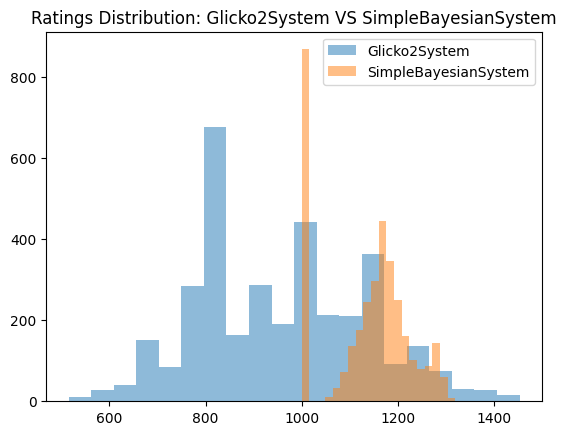

--------------------------------------------------
COMPARING Glicko2System vs BayesianSystem
--------------------------------------------------
Rating Difference:
count    3524.000000
mean      -40.517791
std       172.797096
min      -475.125444
25%      -161.998029
50%       -50.913775
75%        96.310628
max       448.063000
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean      147.678773
std        98.416377
min         0.000000
25%        71.816586
50%       161.936184
75%       203.244681
max       475.125444
dtype: float64


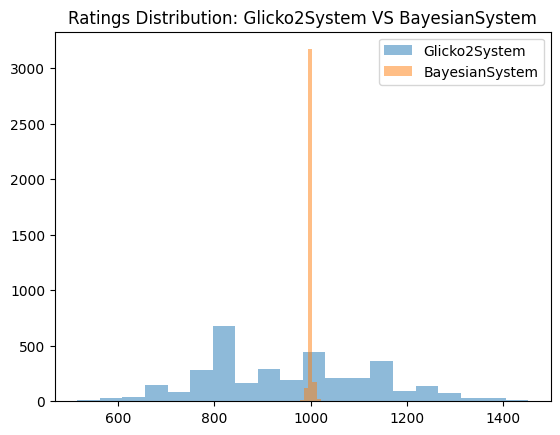

--------------------------------------------------
COMPARING SimpleBayesianSystem vs BayesianSystem
--------------------------------------------------
Rating Difference:
count    3524.000000
mean      134.158568
std        88.157868
min         0.312866
25%        67.012115
50%       157.671365
75%       188.697191
max       319.313804
dtype: float64
Absolute Rating Difference:
count    3524.000000
mean      134.158568
std        88.157868
min         0.312866
25%        67.012115
50%       157.671365
75%       188.697191
max       319.313804
dtype: float64


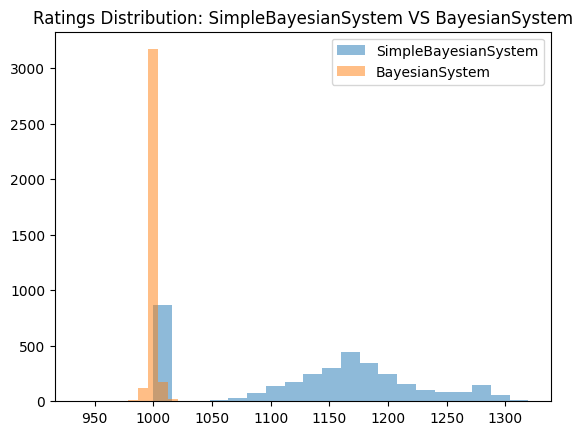

In [41]:
for rating_system_a, rating_system_b in combinations(rating_systems, 2):
    rating_system_a_name = rating_system_a.__class__.__name__
    rating_system_b_name = rating_system_b.__class__.__name__

    print("-" * 50)
    print(f"COMPARING {rating_system_a_name} vs {rating_system_b_name}")
    print("-" * 50)

    compare_rating_systems_players_rating_pair(
        df_ratings, rating_system_a_name, rating_system_b_name
    )

### Rank

In [42]:
df_ranking = compare_rating_systems_players_rank(rating_systems, players)

--------------------------------------------------
COMPARING EloSystem vs Glicko2System
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       524.722834
min     -1577.000000
25%      -371.000000
50%       -67.500000
75%       325.000000
max      2091.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      414.795687
std       321.293874
min         0.000000
25%       165.000000
50%       357.000000
75%       575.000000
max      2091.000000
dtype: float64


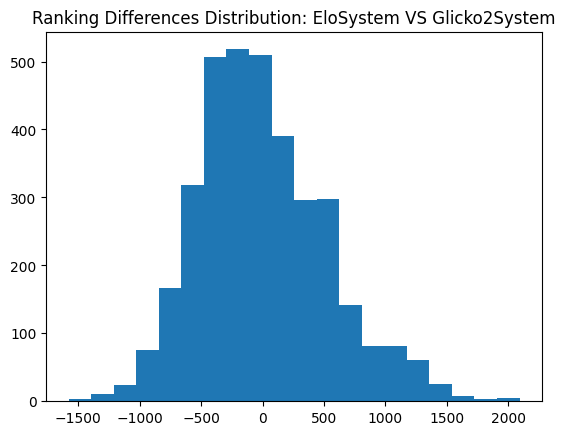

--------------------------------------------------
COMPARING EloSystem vs SimpleBayesianSystem
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       701.458628
min     -1800.000000
25%      -514.000000
50%       -21.500000
75%       546.250000
max      2053.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      583.009648
std       389.932656
min         0.000000
25%       254.750000
50%       527.000000
75%       874.250000
max      2053.000000
dtype: float64


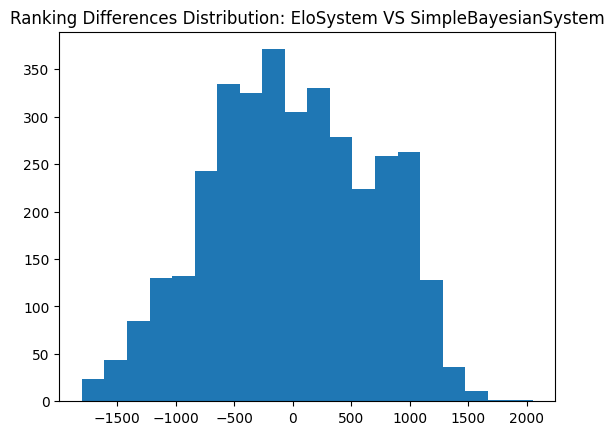

--------------------------------------------------
COMPARING EloSystem vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       493.455015
min     -2926.000000
25%      -128.000000
50%        43.000000
75%       205.250000
max      3010.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      297.070942
std       393.981798
min         0.000000
25%        82.000000
50%       174.000000
75%       343.000000
max      3010.000000
dtype: float64


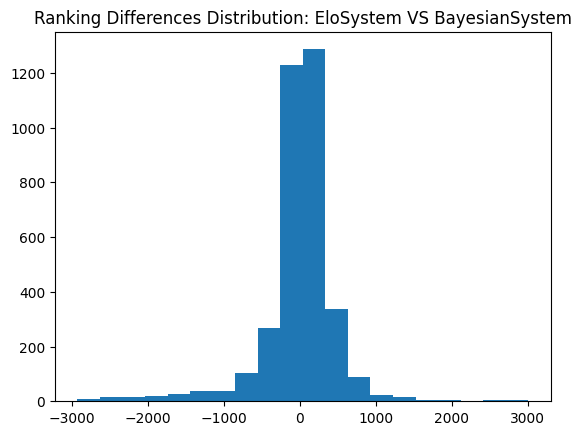

--------------------------------------------------
COMPARING Glicko2System vs SimpleBayesianSystem
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       413.255475
min     -1553.000000
25%      -261.000000
50%        12.000000
75%       273.000000
max      2172.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      328.610102
std       250.529115
min         0.000000
25%       112.000000
50%       266.500000
75%       537.250000
max      2172.000000
dtype: float64


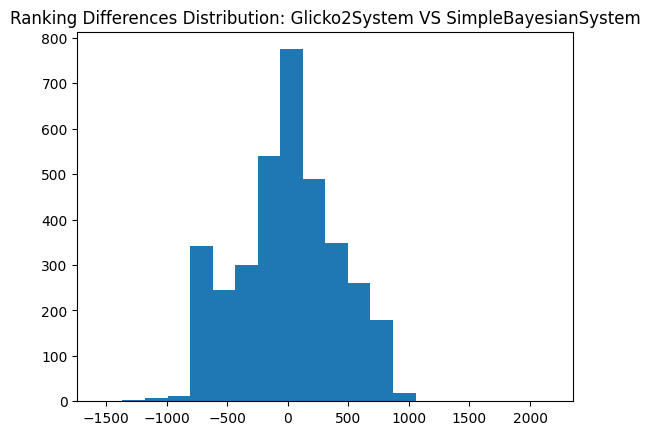

--------------------------------------------------
COMPARING Glicko2System vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       578.002751
min     -1840.000000
25%      -350.000000
50%        94.000000
75%       434.000000
max      1040.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      458.562429
std       351.778327
min         0.000000
25%       169.000000
50%       414.000000
75%       653.000000
max      1840.000000
dtype: float64


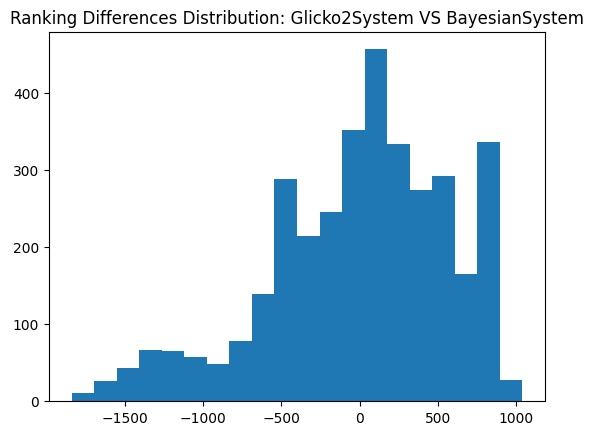

--------------------------------------------------
COMPARING SimpleBayesianSystem vs BayesianSystem
--------------------------------------------------
Ranking Difference:
count    3524.000000
mean        0.000000
std       794.615162
min     -2162.000000
25%      -586.000000
50%         5.500000
75%       565.000000
max      1768.000000
dtype: float64
Absolute Ranking Difference:
count    3524.000000
mean      650.244041
std       456.591641
min         0.000000
25%       272.750000
50%       577.000000
75%       953.000000
max      2162.000000
dtype: float64


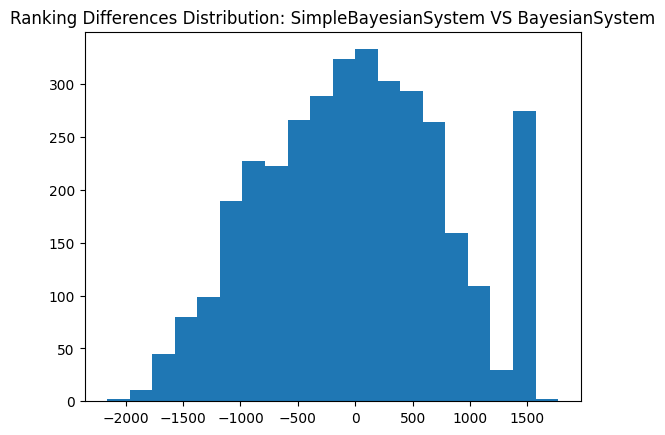

In [43]:
for rating_system_a, rating_system_b in combinations(rating_systems, 2):
    rating_system_a_name = rating_system_a.__class__.__name__
    rating_system_b_name = rating_system_b.__class__.__name__

    print("-" * 50)

    print(f"COMPARING {rating_system_a_name} vs {rating_system_b_name}")

    print("-" * 50)

    compare_rating_systems_players_ranking_pair(
        df_ranking, rating_system_a_name, rating_system_b_name
    )

### Winning odds

In [44]:
compare_rating_systems_winning_odds(
    rating_systems, player_1_name, player_2_name, is_first=False
)

Winning probability: 77.40
Loosing probability: 22.60
Drawing probability: 0.00
Winning probability: 73.22
Loosing probability: 26.78
Drawing probability: 0.00
Winning probability: 58.89
Loosing probability: 41.11
Drawing probability: 0.00
Winning probability: 32.90
Loosing probability: 39.95
Drawing probability: 27.15


,winning_proba,loosing_proba,drawing_proba
EloSystem,77.395001,22.604999,0.000000
Glicko2System,73.216376,26.783624,0.000000
SimpleBayesianSystem,58.891955,41.108045,0.000000
BayesianSystem,32.904344,39.946542,27.149114


In [45]:
compare_rating_systems_winning_odds(
    rating_systems, player_1_name, player_2_name, is_first=True
)

Winning probability: 77.40
Loosing probability: 22.60
Drawing probability: 0.00
Winning probability: 73.22
Loosing probability: 26.78
Drawing probability: 0.00
Winning probability: 58.89
Loosing probability: 41.11
Drawing probability: 0.00
Winning probability: 41.71
Loosing probability: 31.32
Drawing probability: 26.98


,winning_proba,loosing_proba,drawing_proba
EloSystem,77.395001,22.604999,0.000000
Glicko2System,73.216376,26.783624,0.000000
SimpleBayesianSystem,58.891955,41.108045,0.000000
BayesianSystem,41.705112,31.317509,26.977379


---------------------